In [1]:
import pandas as pd
import numpy as np
import tkinter as tk
from tkinter import filedialog

sample_name = r'MAPbI$_3$ ' + "Control"#w/ 1 mol% 4-ABA"
target_time = 375 #end of experiment in seconds

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(r"K:\printz_Apr2024\MAPI_YL\working_files\MAPI_Control_S1_18_30min\output\PL_FitResults.csv")
print(df.columns)

time_column = df.columns[0]
peak_position_column = df.columns[3]
fwhm_column = df.columns[4]
# Drop rows where the specific column has NaN values
df_clean = df.dropna(subset=peak_position_column)
# Display the cleaned DataFrame
df_clean


Index(['Fit-Time_MAPI_Control_S1_18_30min',
       'Peak1Area_MAPI_Control_S1_18_30min',
       'Peak1Amplitude_MAPI_Control_S1_18_30min',
       'Peak1Pos_MAPI_Control_S1_18_30min',
       'Peak1FWHM_MAPI_Control_S1_18_30min',
       'Peak1Alpha_MAPI_Control_S1_18_30min'],
      dtype='object')


,Fit-Time_MAPI_Control_S1_18_30min,Peak1Area_MAPI_Control_S1_18_30min,Peak1Amplitude_MAPI_Control_S1_18_30min,Peak1Pos_MAPI_Control_S1_18_30min,Peak1FWHM_MAPI_Control_S1_18_30min,Peak1Alpha_MAPI_Control_S1_18_30min
0,0.000000,1.685089e-19,1.153353e+00,1.651186,0.000080,9.967197e-01
1,0.499807,1.606287e-11,2.002119e-02,1.671634,0.004139,7.666188e-06
2,0.999615,1.113223e-34,3.409154e-16,1.437850,0.000080,6.645591e-04
3,1.499422,4.870139e-28,7.315397e-11,1.627098,0.000080,9.946523e-01
4,1.999230,7.819227e-09,2.384248e-03,1.735809,0.001692,3.927641e-01
...,...,...,...,...,...,...
1194,596.770048,8.397215e+00,6.536692e+01,1.596305,0.120683,1.114650e-10
1195,597.269856,8.520073e+00,6.631620e+01,1.596239,0.120664,1.458593e-03
1196,597.769663,8.396358e+00,6.544856e+01,1.596266,0.120285,1.101800e-02
1197,598.269471,8.537484e+00,6.630895e+01,1.596512,0.120375,2.720241e-02


# Plot FWHM vs. time


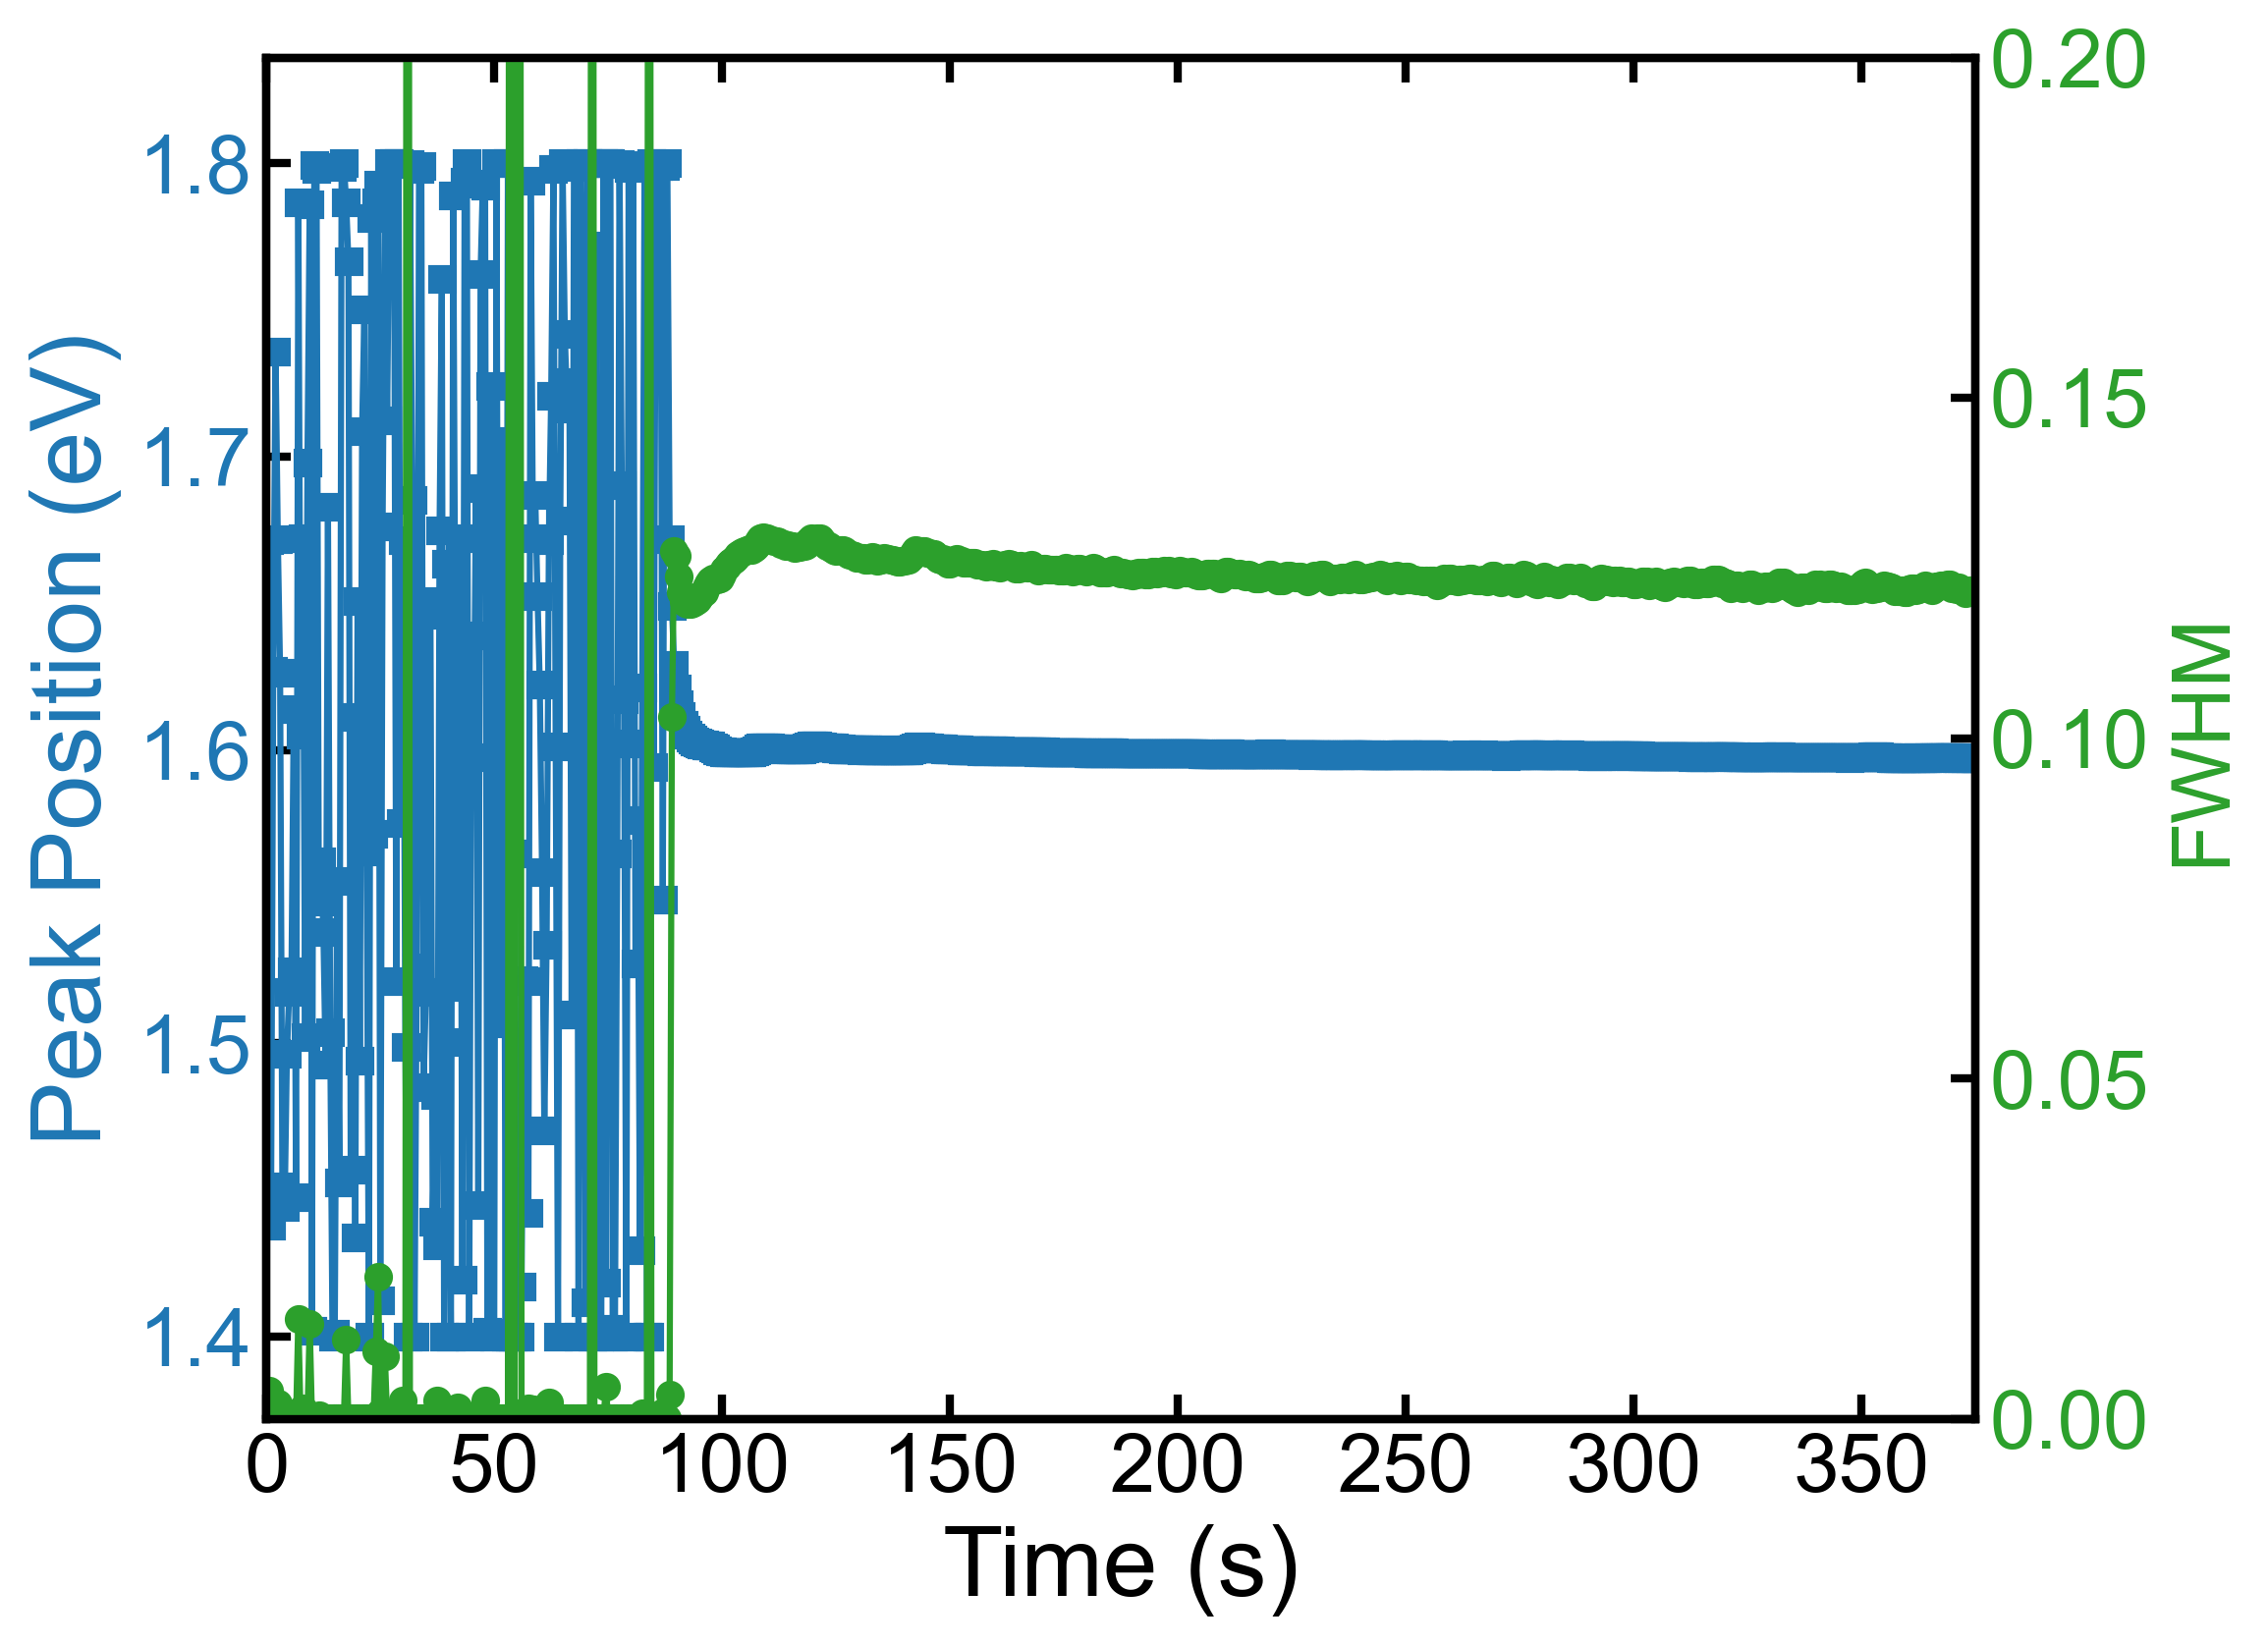

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Extract data
fwhm_values = df_clean[fwhm_column].iloc[1:].to_numpy()
time_values = df_clean[time_column].iloc[1:].to_numpy()
peak_positions = df_clean[peak_position_column].iloc[1:].to_numpy()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)

# Plot peak position (left y-axis)
color2 = 'tab:blue'
ax1.plot(time_values, peak_positions, marker='s', color=color2, label='Peak Position')
ax1.set_ylabel('Peak Position (eV)', color=color2, fontsize=24, fontname='Arial')
ax1.tick_params(axis='y', labelcolor=color2, direction='in', width=2, length=6, labelsize=20, right=True)
ax1.set_ylim(min(peak_positions)*0.98, max(peak_positions)*1.02)
ax1.set_xlabel('Time (s)', fontsize=24, fontname='Arial', color='black')

# Apply X-axis tick styling
ax1.tick_params(axis='x', direction='in', width=2, length=6, labelsize=20, color='black', top=True)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax1.locator_params(axis='y', nbins=5)
ax1.grid(False)

# Style tick label fonts
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontname('Arial')

# Thicken spines
for spine in ax1.spines.values():
    spine.set_linewidth(2)
ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(True)

# Twin axis for FWHM
ax2 = ax1.twinx()
color1 = 'tab:green'
ax2.plot(time_values, fwhm_values, marker='o', color=color1, label='FWHM')
ax2.set_ylabel('FWHM', color=color1, fontsize=20, fontname='Arial')
ax2.tick_params(axis='y', labelcolor=color1, direction='in', width=2, length=6, labelsize=20)
ax2.set_ylim(0, 0.2)
ax2.locator_params(axis='y', nbins=5)

for label in ax2.get_yticklabels():
    label.set_fontname('Arial')
for spine in ax2.spines.values():
    spine.set_linewidth(2)

# Set shared X limits
ax2.set_xlim(0, target_time)

# Adjust subplot to give space for the right y-axis label
fig.subplots_adjust(right=0.85)

# Save png of Figure with full bounding box
peak_fwhm_path = "peak_fwhm_plot.png"
plt.savefig(peak_fwhm_path, bbox_inches='tight')

# Show the plot
plt.show()

# Solve Brus Equation for d

# Test integral values

In [3]:
import numpy as np
from scipy.constants import hbar, pi, e, epsilon_0, m_e, h #these are in SI
from scipy.integrate import quad

def integrand(r, R, epsilon, N):
    """Function to integrate."""
    # sum over k from 1 to N
    sum_k = sum(
        ((r / R) ** (2 * k)) * (k + 1) / ((epsilon + 1) * k + 1)  # equation 11
        for k in range(1, N + 1)
    )
    return np.sin(pi * r / R) ** 2 * sum_k

def compute_integral(R, epsilon_r, epsilon_med, N=10):
    
    epsilon = epsilon_r / epsilon_med  # relative permittivity ratio 
    
    # Prefactor outside the integral
    prefactor = (e ** 2 * (epsilon - 1)) / (2 * pi * R ** 2 * epsilon_r * epsilon_0)

    # Perform numerical integration from 0 to R
    integral_val, _ = quad(integrand, 0, R, args=(R, epsilon, N))

    return prefactor * integral_val

# Example usage:
R = 20e-9  # radius in meters
epsilon_med = 36.7   # dielectric constant of surrounding
epsilon_r = 7.5  # dielectric constant of CdSe
N = 20  # number of terms in the sum

# Constants

me_star = 0.138  # effective mass of electron in units of m_e
mh_star = 0.118  # effective mass of hole in units of m_e
me = me_star * m_e # effective mass of electron in kg
mh = mh_star * m_e # effective mass of hole in kg

red_mass_inv = 1 / me + 1 / mh 

term1 = (2 * pi**2 * hbar**2 / (2*R)**2) * red_mass_inv
term2 = (3.572 * e**2) / ( epsilon_r * epsilon_0 * 4 * pi * 2 * R)

term3 = result = compute_integral(R, epsilon_r, epsilon_med, N)
print(f"term1 (eV): {term1/e}, term2 (eV): {term2/e}, term3 (eV): {term3/e}")


term1 (eV): 0.014778881340402755, term2 (eV): 0.01714517787136048, term3 (eV): -0.003741700211089009


# Attempt to solve iteratively for integral


Skipping negative delta_E_eV: -0.15953283262146623 for Eg_meas_eV: 1.4378496180275302
Skipping negative delta_E_eV: -0.14610262078477554 for Eg_meas_eV: 1.4512798298642209
Skipping negative delta_E_eV: -0.15311579192217017 for Eg_meas_eV: 1.4442666587268262
Skipping negative delta_E_eV: -0.10104672888259092 for Eg_meas_eV: 1.4963357217664055
Skipping negative delta_E_eV: -0.07991025437445787 for Eg_meas_eV: 1.5174721962745386
Skipping negative delta_E_eV: -0.07290223942990504 for Eg_meas_eV: 1.5244802112190914
Skipping negative delta_E_eV: -0.14979682489551793 for Eg_meas_eV: 1.4475856257534785
Skipping negative delta_E_eV: -0.09509937268035107 for Eg_meas_eV: 1.5022830779686454
Skipping negative delta_E_eV: -0.1953824506489965 for Eg_meas_eV: 1.402
Skipping negative delta_E_eV: -0.04898093637748091 for Eg_meas_eV: 1.5484015142715155
Skipping negative delta_E_eV: -0.035399094618780325 for Eg_meas_eV: 1.561983356030216
Skipping negative delta_E_eV: -0.05944027700963317 for Eg_meas_eV: 1

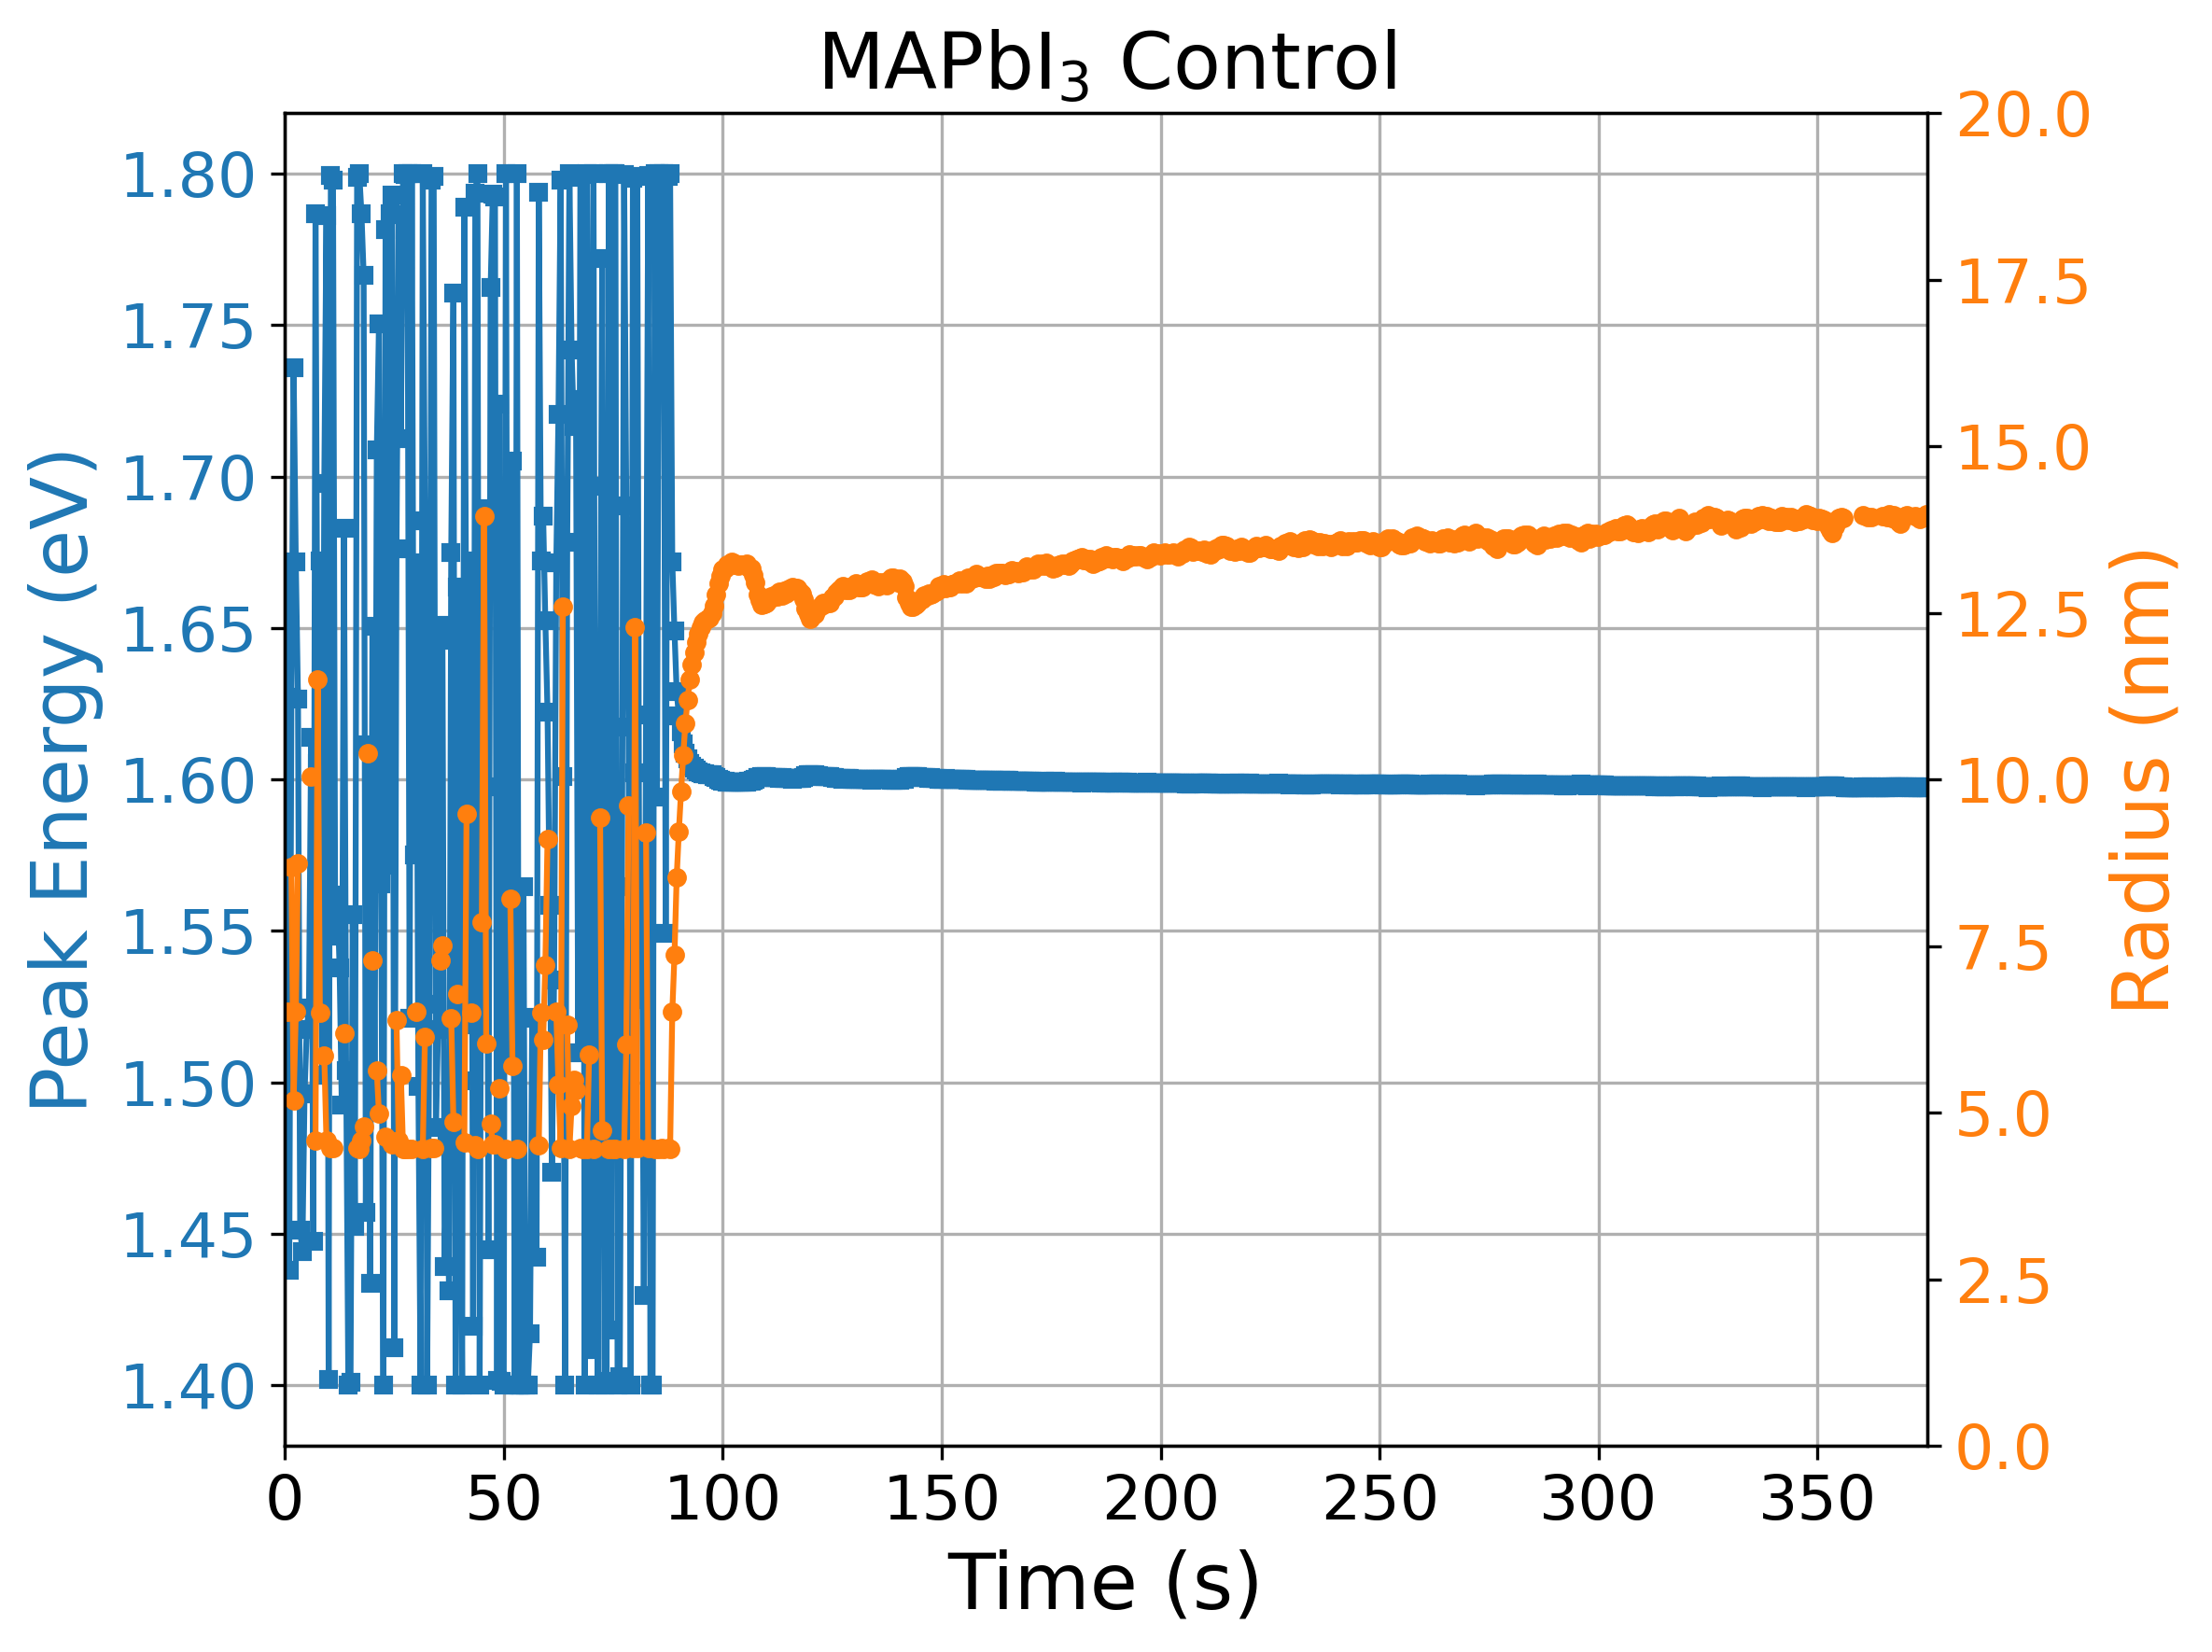

In [4]:
import numpy as np
from scipy.constants import hbar, e, epsilon_0, pi
from scipy.integrate import quad
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def integrand(r, R, epsilon_pvk, epsilon_env, N):
    """Function to integrate."""
    # sum over k from 1 to N
    sum_k = sum(
        ((r / R) ** (2 * k)) * (k + 1) / ((epsilon_pvk / epsilon_env + 1) * k + 1)  # equation 11
        for k in range(1, N + 1)
    )
    return np.sin(pi * r / R) ** 2 * sum_k

def compute_integral(R, epsilon_pvk, epsilon_env, N=10):
    
    # Perform numerical integration from 0 to R
    integral_val, _ = quad(integrand, 0, R, args=(R, epsilon_pvk, epsilon_env, N))

    return integral_val

def exciton_energy_eq(R, E_ex, me, mh, epsilon_pvk, epsilon_env, N=10):
    A = (h**2 / 8) * (1 / me + 1 / mh)
    B = 1.8 * e**2 / (4 * pi * epsilon_pvk * epsilon_0)
    
    # Prefactor outside the integral
    prefactor = (e ** 2 * (epsilon_pvk / epsilon_env - 1)) / (2 * pi * epsilon_pvk * epsilon_0)

    integral = compute_integral(R, epsilon_pvk, epsilon_env, N)
    C = prefactor * integral
    return A / R**2 - B / R - E_ex * e + C / R**2#J

def solve_radius(E_ex, me, mh, epsilon_pvk, epsilon_env, N=10):
    func = lambda R: exciton_energy_eq(R, E_ex, me, mh, epsilon_pvk, epsilon_env, N)
    sol = root_scalar(func, bracket=[1e-10, 2e-8], method='brentq')
    if sol.converged:
        return sol.root
    else:
        raise RuntimeError("Root finding failed.")
    

# Example usage
# delta_E_eV = 1 # Example value for delta_E in eV
epsilon_pvk = 7.5 # dielectric constant of perovskite
epsilon_env = 40 # dielectric constant of surrounding medium (e.g., vacuum)
    
me_star = 0.138  # effective mass of electron in units of m_e
mh_star = 0.118  # effective mass of hole in units of m_e
me = me_star * m_e # effective mass of electron in kg
mh = mh_star * m_e # effective mass of hole in kg

jitter = 1e-9 # in eV

# Eg_bulk_eV = df_clean[peak_position_column].iloc[-1].to_numpy()[0] - jitter # Get the last value of the peak position column, subtract jitter for numerical covergence

closest_idx = (df_clean[time_column] - target_time).abs().idxmin()
Eg_bulk_eV = df_clean.loc[closest_idx, peak_position_column] # Get the peak position at the closest time to target_time, subtract jitter for numerical convergence

# --- Solve for d for each row ---
radii_nm = []

# R_sol = solve_radius(delta_E_eV, me, mh, epsilon_pvk, epsilon_env, N=10)
# R_sol * 1e9  # Convert to nm for display

for Eg_meas_eV in df_clean[peak_position_column].iloc[1:].to_numpy():
    delta_E_eV = Eg_meas_eV - Eg_bulk_eV  # Calculate the energy difference in eV
    
    if delta_E_eV < 0:
        print(f"Skipping negative delta_E_eV: {delta_E_eV} for Eg_meas_eV: {Eg_meas_eV}")
        radii_nm.append(np.nan)
        continue  # Skip negative values
    radius = solve_radius(delta_E_eV, me, mh, epsilon_pvk, epsilon_env, N=20)
    
    # print(f"delta_E_eV: {delta_E_eV}, radius (nm): {radius * 1e9}")  # Convert radius to nm for display

    radii_nm.append(radius * 1e9)  # Append the radius in meters


radii_nm

# df_clean['diameter_nm'] = np.array(diameters_nm)
time_s = df_clean[time_column].iloc[1:].to_numpy()  # Get the time values
peak_energy = df_clean[peak_position_column].iloc[1:].to_numpy()

fs = 20
tick_fs = 16  # font size for tick labels
marker_size = 4  # size of the plot markers

# Create a single set of axes
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)

# Plot Peak Energy on left y-axis
color1 = 'tab:blue'
ax1.plot(time_s, peak_energy, marker='s', markersize=marker_size, color=color1, label='Peak Energy')
ax1.set_xlabel('Time (s)', fontsize=fs)
ax1.set_ylabel('Peak Energy (eV)', color=color1, fontsize=fs)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=tick_fs)
ax1.tick_params(axis='x', labelsize=tick_fs)
ax1.set_title(f'{sample_name}', fontsize=fs)
ax1.grid(True)
ax1.set_xlim(0, target_time)  # Set x-axis limits

# Create twin y-axis
ax2 = ax1.twinx()

# Plot Radius on right y-axis
color2 = 'tab:orange'
ax2.plot(time_s, radii_nm, marker='o', markersize=marker_size, color=color2, label='Radius')
ax2.set_ylabel('Radius (nm)', color=color2, fontsize=fs)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=tick_fs)
ax2.set_ylim(0, 20)

# Layout and show
fig.tight_layout()
plt.show()


# Ensure they are 1D numpy arrays
time_s = np.array(time_s).flatten()
peak_energy = np.array(peak_energy).flatten()
flattened_radii_nm = np.array(radii_nm).flatten()

# # Check lengths
# print("time_s:", time_s.shape)
# print("peak_energy:", peak_energy.shape)
# print("flattened_radii_nm:", flattened_radii_nm.shape)

# Create figure
fig = go.Figure()

# Peak Energy Trace (Left Y-Axis)
fig.add_trace(go.Scatter(
    x=time_s,
    y=peak_energy,
    mode='lines+markers',
    name='Peak Energy (eV)',
    marker=dict(symbol='square', color='blue'),
    line=dict(color='blue'),
    yaxis='y1'
))

# Radius Trace (Right Y-Axis)
fig.add_trace(go.Scatter(
    x=time_s,
    y=radii_nm,
    mode='lines+markers',
    name='Radius (nm)',
    marker=dict(symbol='circle', color='orange'),
    line=dict(color='orange'),
    yaxis='y2'
))

# Layout: Titles, Axes, and Styling
fig.update_layout(
    title=f'{sample_name}',
    xaxis=dict(title='Time (s)',
               range=[0, target_time],
               ),
    
    yaxis=dict(
        title=dict(
            text='Peak Energy (eV)',
            font=dict(color='blue')  # Correct way to set title font color
        ),
        tickfont=dict(color='blue'),
    ),
    
    yaxis2=dict(
        title=dict(
            text='Radius (nm)',
            font=dict(color='orange')  # Correct way to set title font color
        ),
        tickfont=dict(color='orange'),
        overlaying='y',
        side='right',
        range=[0, 20]
    ),
    
    font=dict(size=fs),
    legend=dict(x=0.02, y=0.98),
    template='plotly_white',
    # width=768,    # 8 inches
    # height=576,   # 6 inches
)

fig.show()

# Identify different regions and fit

C:\Users\Aj\AppData\Local\Temp\ipykernel_34476\4007000196.py:61: OptimizeWarning:

Covariance of the parameters could not be estimated

C:\Users\Aj\AppData\Local\Temp\ipykernel_34476\4007000196.py:78: OptimizeWarning:

Covariance of the parameters could not be estimated



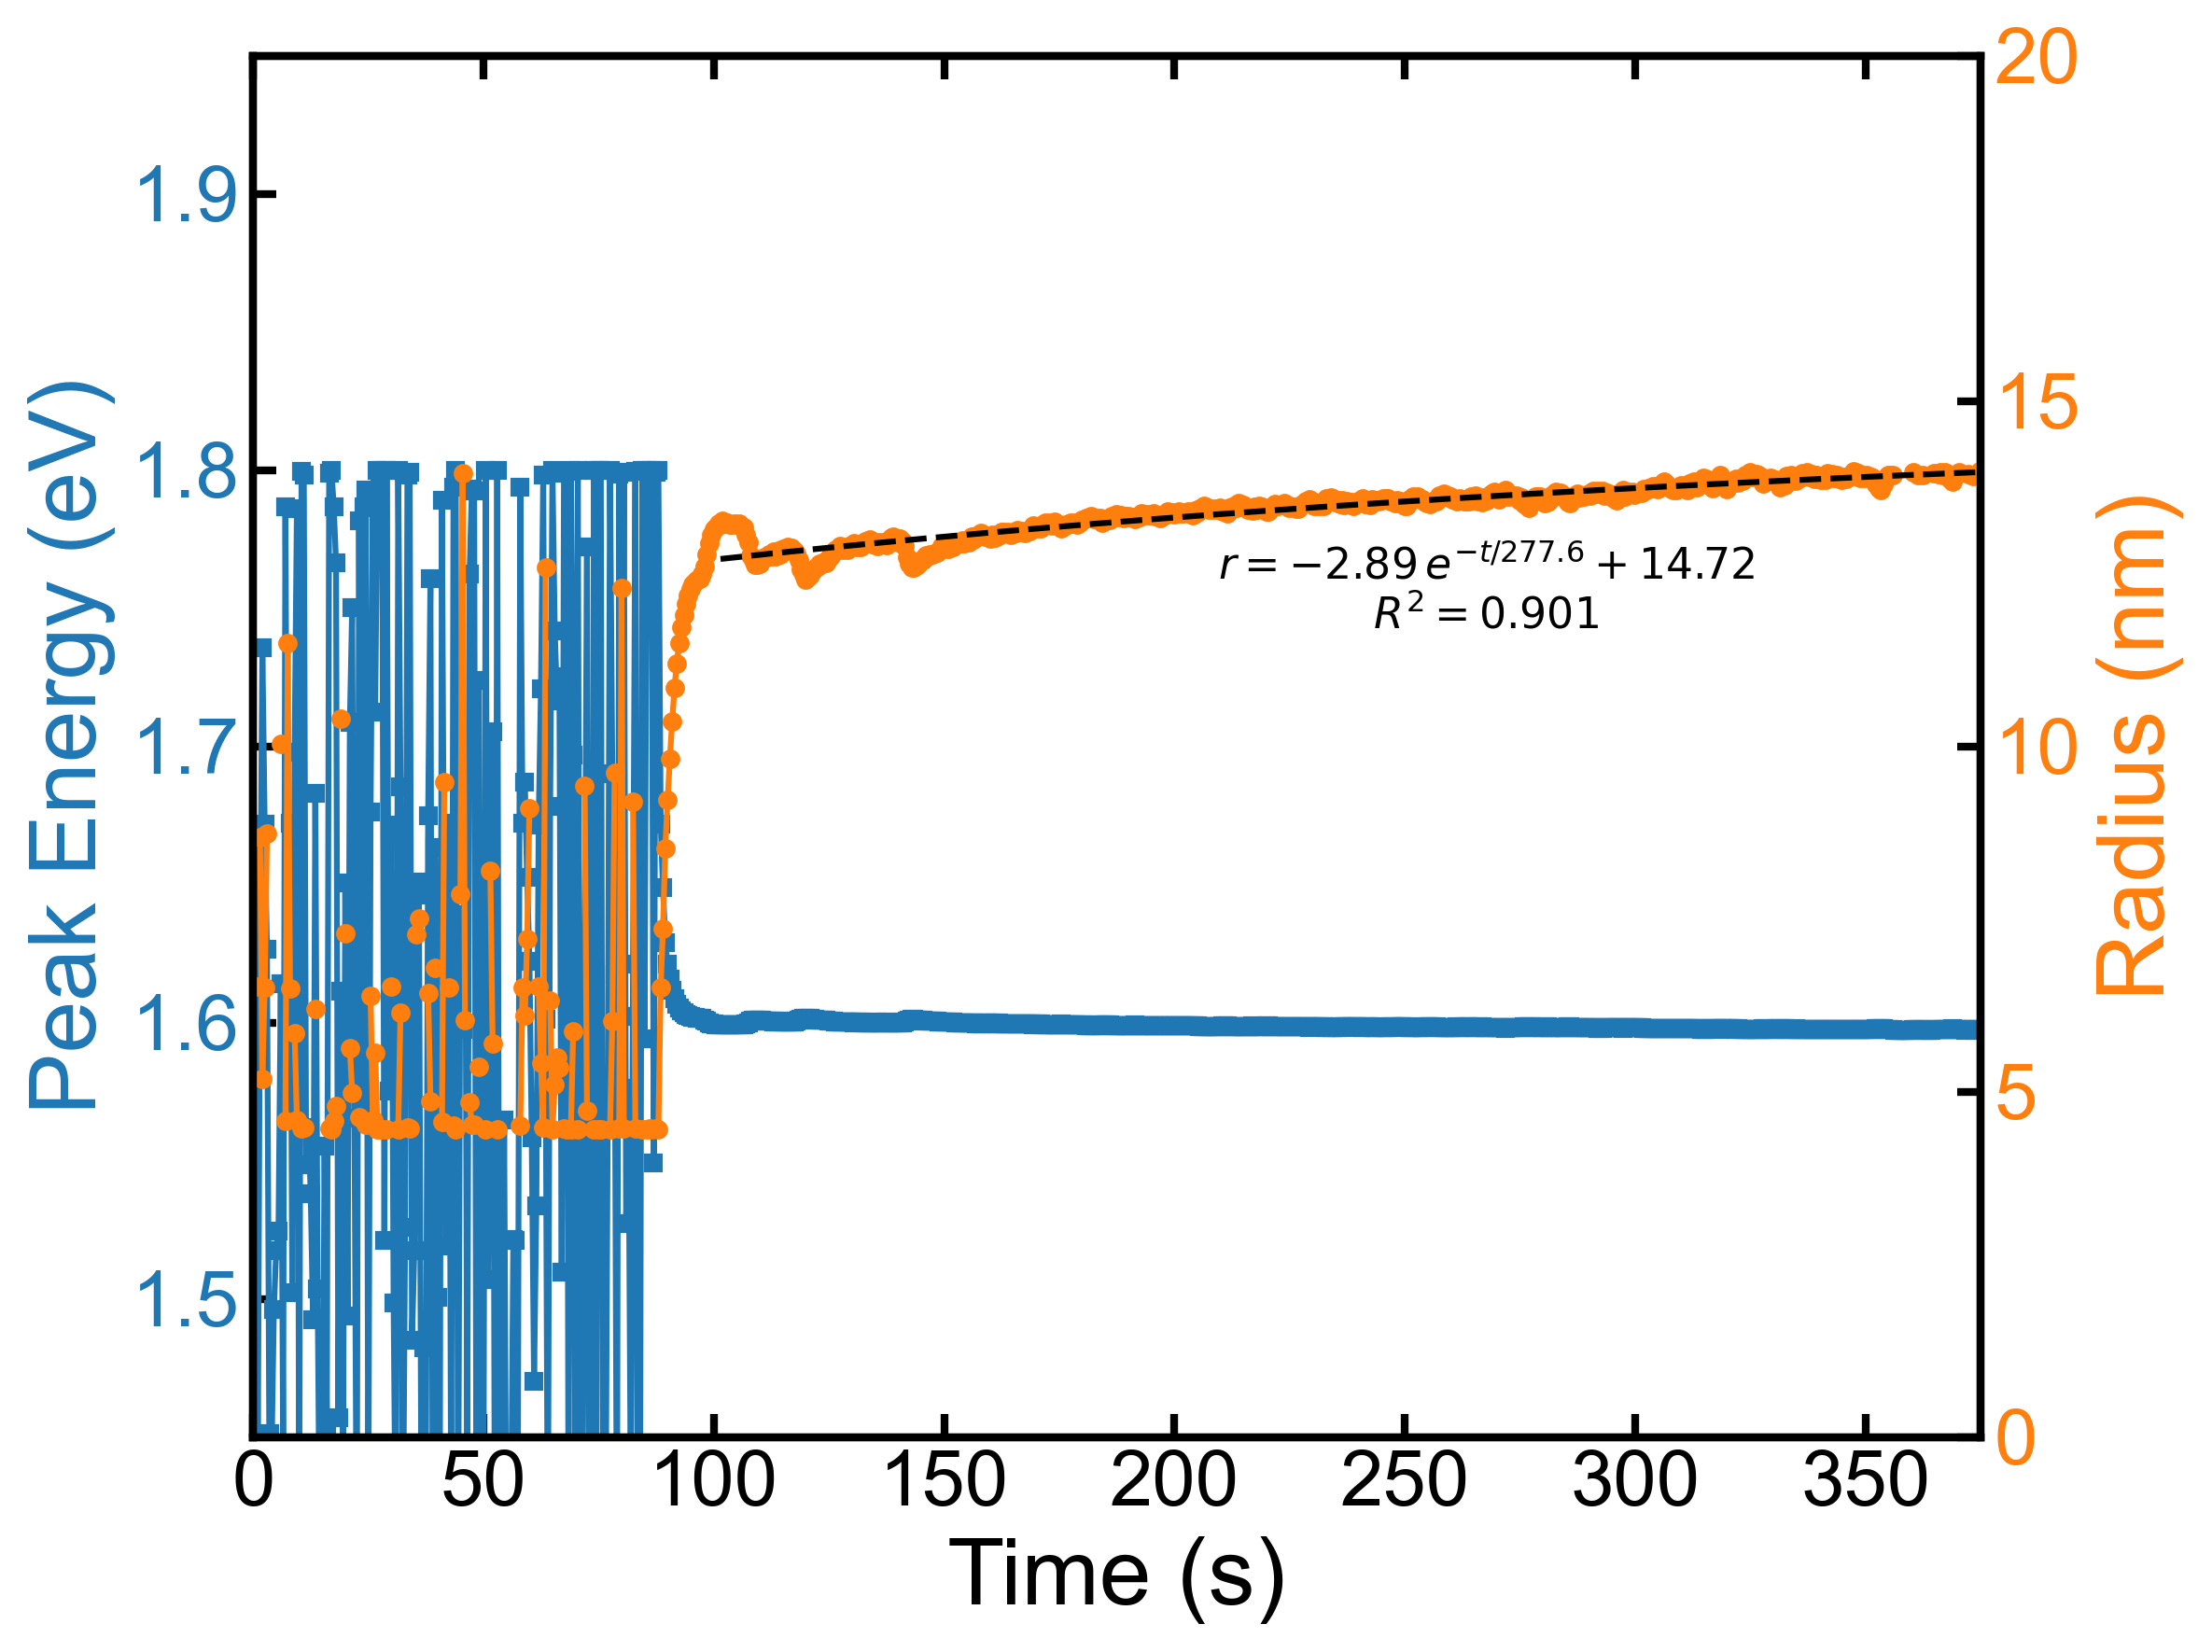

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import plotly.graph_objects as go
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker
import pandas as pd

# Define time threshold for noise removal
noise_threshold = 0

# --- Define explicit time regions (in seconds) ---
region1 = (38, 83)
region2 = (83, 101)
region3 = (101, target_time - 1)

# --- Fit helper function ---
def fit_linear_segment(t_full, y_full, t_range):
    t = np.array(t_full).flatten()
    y = np.array(y_full).flatten()
    mask = (t >= t_range[0]) & (t <= t_range[1]) & ~np.isnan(t) & ~np.isnan(y)
    t_seg = t[mask]
    y_seg = y[mask]
    slope, intercept, *_ = linregress(t_seg, y_seg)
    y_fit = slope * t_seg + intercept
    return t_seg, y_seg, y_fit, slope, intercept

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# # --- Define biexponential function ---
# def biexp(t, A1, tau1, A2, tau2, C):
#     return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C

# Filter for time > threshold
mask = time_s > noise_threshold
mask = mask.flatten()  # Ensure mask is a 1D array
time_filtered = time_s[mask]
energy_filtered = peak_energy[mask]
radius_filtered = np.array(radii_nm)[mask]

# --- Create boolean masks for each region ---
mask1 = (time_filtered >= region1[0]) & (time_filtered <= region1[1])
mask2 = (time_filtered >= region2[0]) & (time_filtered <= region2[1])
mask3 = (time_filtered >= region3[0]) & (time_filtered <= region3[1])

# --- Extract time and radius data ---
t1, r1 = time_filtered[mask1], radius_filtered[mask1]
t2, r2 = time_filtered[mask2], radius_filtered[mask2]
t3, r3 = time_filtered[mask3], radius_filtered[mask3]

# # --- Fit each region ---

# # Region 1 fit
# Remove NaNs and infs from t1 and r1
valid_mask1 = np.isfinite(t1) & np.isfinite(r1)
t1_clean = t1[valid_mask1]
r1_clean = r1[valid_mask1]
p0_1 = [1, 50, np.min(r1)]
bounds = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
params1, _ = curve_fit(exp_decay, t1_clean, r1_clean, p0=p0_1, bounds=bounds)

A1, tau1, C1 = params1
r1_exp = exp_decay(t1, *params1)

# R² for Region 1
residuals1 = r1_clean - exp_decay(t1_clean, *params1)
ss_res1 = np.sum(residuals1**2)
ss_tot1 = np.sum((r1_clean - np.mean(r1_clean))**2)
r_squared1 = 1 - (ss_res1 / ss_tot1)

# # Region 2 fit
# Remove NaNs and infs from t2 and r2
valid_mask2 = np.isfinite(t2) & np.isfinite(r2)
t2_clean = t2[valid_mask2]
r2_clean = r2[valid_mask2]
p0_2 = [1, 50, np.min(r2)]
params2, _ = curve_fit(exp_decay, t2_clean, r2_clean, p0=p0_2, bounds=bounds)

A2, tau2, C2 = params2
r2_exp = exp_decay(t2, *params2)

# R² for Region 2
residuals2 = r2_clean - exp_decay(t2_clean, *params2)
ss_res2 = np.sum(residuals2**2)
ss_tot2 = np.sum((r2_clean - np.mean(r2_clean))**2)
r_squared2 = 1 - (ss_res2 / ss_tot2)

# # Region 3 fit
# Remove NaNs and infs from t3 and r3
valid_mask3 = np.isfinite(t3) & np.isfinite(r3)
t3_clean = t3[valid_mask3]
r3_clean = r3[valid_mask3]
# p0_3 = [1, 50, np.min(r3)]
p0_3 = [1, 50, -1]
params3, _ = curve_fit(exp_decay, t3_clean, r3_clean, p0=p0_3, bounds=bounds)
A3, tau3, C3 = params3
r3_exp = exp_decay(t3, *params3)

# R² for Region 3
residuals3 = r3_clean - exp_decay(t3_clean, *params3)
ss_res3 = np.sum(residuals3**2)
ss_tot3 = np.sum((r3_clean - np.mean(r3_clean))**2)
r_squared3 = 1 - (ss_res3 / ss_tot3)

# Create a single set of axes
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)

# Plot Peak Energy on left y-axis
color1 = 'tab:blue'
ax1.plot(time_filtered, energy_filtered, marker='s', markersize=marker_size,
         color=color1, label='Peak Energy')

ax1.set_xlabel('Time (s)', fontsize=24, fontname='Arial', color='black')
ax1.set_ylabel('Peak Energy (eV)', color=color1, fontsize=24, fontname='Arial')
# ax1.set_title(f'{sample_name}', fontsize=24, fontname='Arial')

# Remove gridlines
ax1.grid(False)

# Ticks styling
ax1.tick_params(axis='x', direction='in', width=2, length=6, labelsize=20, labelcolor='black')
ax1.tick_params(axis='y', direction='in', width=2, length=6, labelsize=20, labelcolor=color1)

# Add ticks to top x-axis (but no labels)
ax1.tick_params(top=True, labeltop=False)  # show ticks only, not labels

# Font settings
for label in ax1.get_xticklabels():
    label.set_fontname('Arial')
for label in ax1.get_yticklabels():
    label.set_fontname('Arial')

# Spine styling
for spine in ax1.spines.values():
    spine.set_linewidth(2)
ax1.spines['top'].set_visible(True)  # ensure top spine is visible

# X and Y limits
ax1.set_xlim(0, target_time)
ax1.set_ylim(1.45, 1.95)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax1.locator_params(axis='y', nbins=5)

# Create twin y-axis
ax2 = ax1.twinx()

# Plot Radius on right y-axis
color2 = 'tab:orange'
ax2.plot(time_filtered, radius_filtered, marker='o', markersize=marker_size,
         color=color2, label='Radius')

ax2.set_ylabel('Radius (nm)', color=color2, fontsize=24, fontname='Arial')
ax2.tick_params(axis='y', labelcolor=color2, direction='in', width=2, length=6, labelsize=20)
for label in ax2.get_yticklabels():
    label.set_fontname('Arial')

for spine in ax2.spines.values():
    spine.set_linewidth(2)

ax2.set_ylim(0, 20)
ax2.locator_params(axis='y', nbins=5)

# --- Add fitted lines to radius ---
ax2.plot(t1, r1_exp, '--', color='black', label='Exp Fit 1')
ax2.plot(t2, r2_exp, '--', color='black', label='Exp Fit 2')
ax2.plot(t3, r3_exp, '--', color='black', label='Exp Fit 3')

# Format equations
eq1 = f"$r = {A1:.2f} \\, e^{{-t / {tau1:.1f}}} + {C1:.2f}$\n$R^2 = {r_squared1:.3f}$"
eq2 = f"$r = {A2:.2f} \\, e^{{-t / {tau2:.1f}}} + {C2:.2f}$\n$R^2 = {r_squared2:.3f}$"
eq3 = f"$r = {A3:.2f} \\, e^{{-t / {tau3:.1f}}} + {C3:.2f}$\n$R^2 = {r_squared3:.3f}$"

# Annotate equations
vertical_offset = -1.0
horizontal_offset = 60
ax2.text(np.mean(t1) + horizontal_offset - 15, np.min(r1_exp) + vertical_offset - 1, eq1,
         fontsize=11, color='black', ha='center', fontname='Arial')
ax2.text(np.mean(t2) + horizontal_offset + 5, np.min(r2_exp) + 3, eq2,
         fontsize=11, color='black', ha='center', fontname='Arial')
ax2.text(np.mean(t3) + horizontal_offset - 30, np.min(r3_exp) + vertical_offset, eq3,
         fontsize=11, color='black', ha='center', fontname='Arial')

# Save png of Figure
energy_radius_path = "energy_radius_plot.png"
plt.savefig(energy_radius_path, bbox_inches='tight')

# Final layout
fig.tight_layout()
plt.show()

# --- Export fit results and raw data to Excel ---
fit_data = {
    "Region": ["Region 1", "Region 2", "Region 3"],
    "A": [A1, A2, A3],
    "Tau": [tau1, tau2, tau3],
    "C": [C1, C2, C3],
    "R_squared": [r_squared1, r_squared2, r_squared3]
}
df_fit = pd.DataFrame(fit_data)

df_raw = pd.DataFrame({
    "Time (s)": time_filtered,
    "Peak Energy (eV)": energy_filtered,
    "Radius (nm)": radius_filtered
})

excel_filename = f"{sample_name}_fit_data.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    df_fit.to_excel(writer, sheet_name="Fit_Parameters", index=False)
    df_raw.to_excel(writer, sheet_name="Raw_Data", index=False)

# Calculate and plot growth rates as a function of time


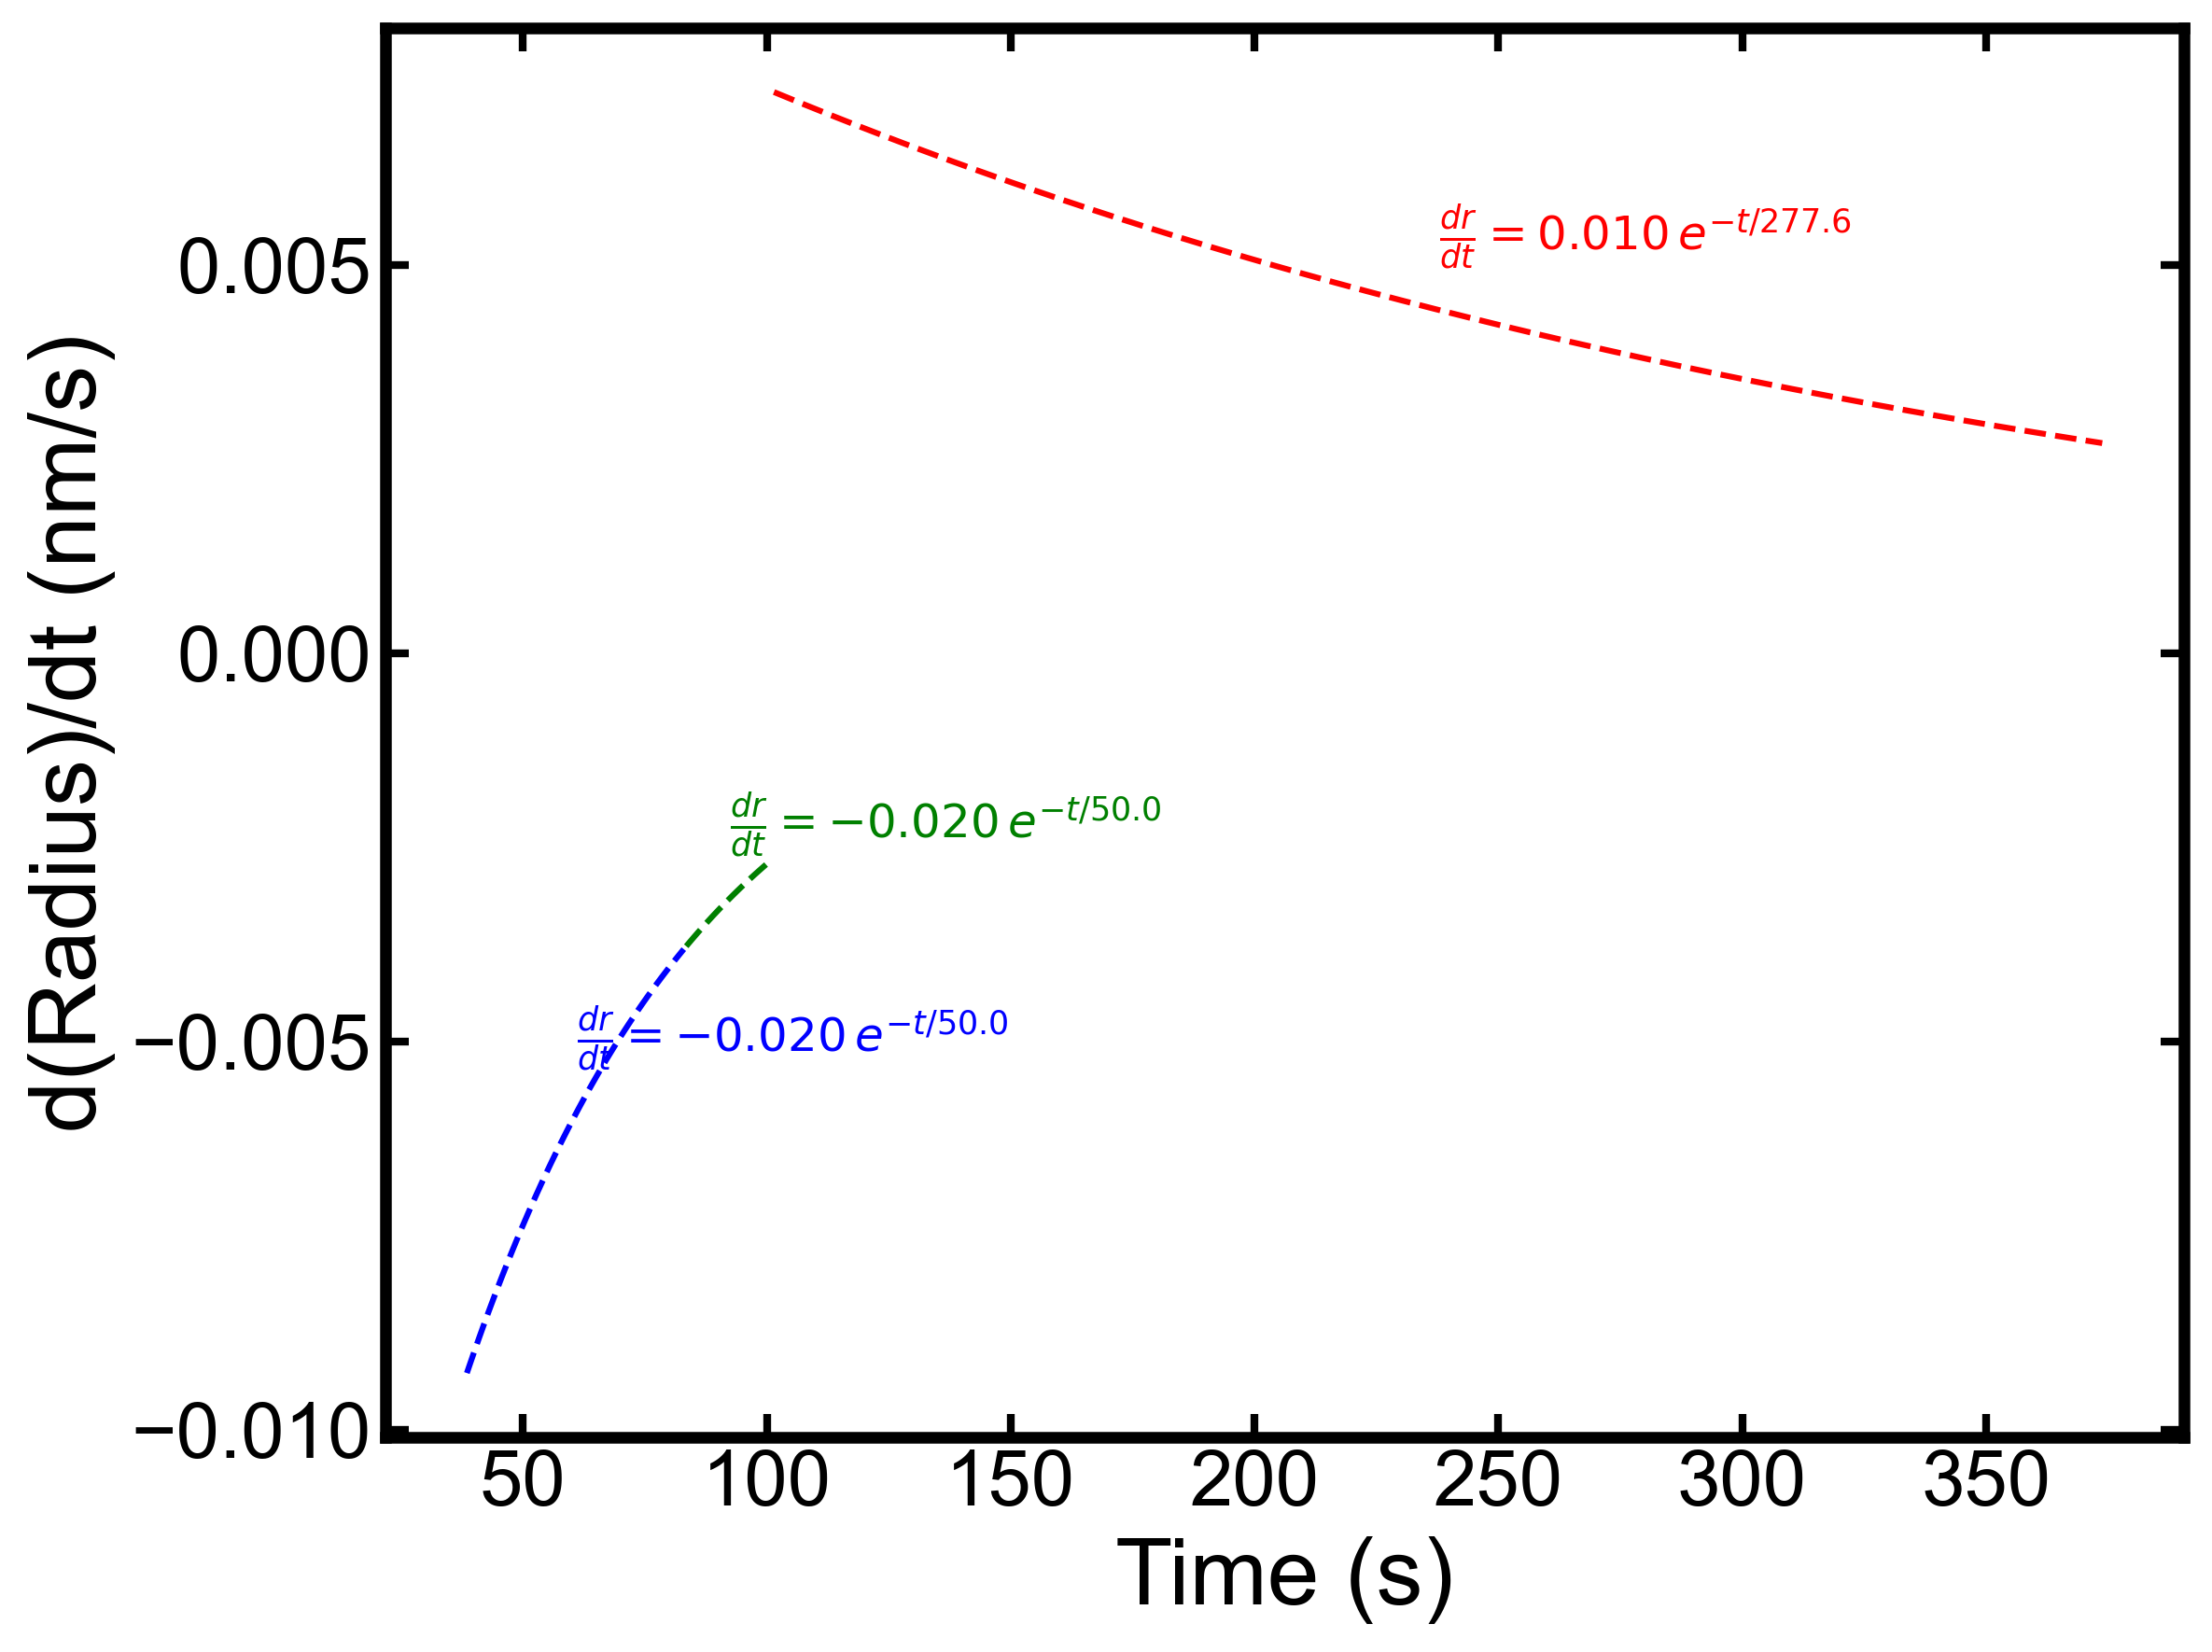

In [6]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as ticker
import numpy as np

# --- Derivative of the exponential decay ---
def exp_decay_derivative(t, A, tau):
    return -A / tau * np.exp(-t / tau)

# --- Compute derivatives for each region ---
drdt1 = exp_decay_derivative(t1, A1, tau1)
drdt2 = exp_decay_derivative(t2, A2, tau2)
drdt3 = exp_decay_derivative(t3, A3, tau3)

# --- Plot the derivatives ---
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.plot(t1, drdt1, '--', color='blue', label='Region 1')
ax.plot(t2, drdt2, '--', color='green', label='Region 2')
ax.plot(t3, drdt3, '--', color='red', label='Region 3')

# Axis labels and title
ax.set_xlabel('Time (s)', fontsize=24, fontname='Arial', color='black')
ax.set_ylabel('d(Radius)/dt (nm/s)', fontsize=24, fontname='Arial', color='black')
# ax.set_title(f'{sample_name}', fontsize=24, fontname='Arial')

# Ticks styling on all sides
ax.tick_params(axis='x', direction='in', top=True, labeltop=False, width=2, length=6, labelsize=20, labelcolor='black')
ax.tick_params(axis='y', direction='in', right=True, labelright=False, width=2, length=6, labelsize=20, labelcolor='black')

# Font for tick labels
for label in ax.get_xticklabels():
    label.set_fontname('Arial')
for label in ax.get_yticklabels():
    label.set_fontname('Arial')

# Spine styling (3 px on all sides)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# X tick spacing: every 50 seconds
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))

# Y tick limit
ax.locator_params(axis='y', nbins=5)

# --- Compute coefficients ---
coeff1 = -A1 / tau1
coeff2 = -A2 / tau2
coeff3 = -A3 / tau3

# --- LaTeX equations for each region ---
eq1 = f"$\\frac{{dr}}{{dt}} = {coeff1:.3f} \\, e^{{-t/{tau1:.1f}}}$"
eq2 = f"$\\frac{{dr}}{{dt}} = {coeff2:.3f} \\, e^{{-t/{tau2:.1f}}}$"
eq3 = f"$\\frac{{dr}}{{dt}} = {coeff3:.3f} \\, e^{{-t/{tau3:.1f}}}$"

# --- Midpoints for label placement ---
idx1 = len(t1) // 2
idx2 = len(t2) // 2
idx3 = len(t3) // 2

# --- 10-pixel upward offset ---
offset = transforms.ScaledTranslation(0, 10 / 72, fig.dpi_scale_trans)
transform = ax.transData + offset

# --- Add text annotations to curves ---
ax.text(t1[idx1], drdt1[idx1], eq1, color='blue', fontsize=12, fontname='Arial',
        ha='left', va='bottom', transform=transform)
ax.text(t2[idx2], drdt2[idx2], eq2, color='green', fontsize=12, fontname='Arial',
        ha='left', va='bottom', transform=transform)
ax.text(t3[idx3], drdt3[idx3], eq3, color='red', fontsize=12, fontname='Arial',
        ha='left', va='bottom', transform=transform)

# Save png of Figure
growth_rate_path = "growth_rate_plot.png"
plt.savefig(growth_rate_path, bbox_inches='tight')

# Final layout
fig.tight_layout()
plt.show()


# Export data to Word file

In [7]:
from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import os

# --- Create a Word document ---
doc = Document()
doc.add_heading(f'Results for {sample_name}', level=1)

# --- Material Parameters ---
doc.add_heading('Material Parameters', level=2)
doc.add_paragraph(f"Effective mass of electron (me*): {me_star:.3f} mₑ")
doc.add_paragraph(f"Effective mass of hole (mh*): {mh_star:.3f} mₑ")
doc.add_paragraph(f"Relative dielectric constant (εᵣ): {epsilon_r:.3f}")
doc.add_paragraph('')

# --- Peak Energy and FWHM vs Time ---
doc.add_heading('Peak Energy and FWHM vs Time', level=2)
doc.add_picture(peak_fwhm_path, width=Inches(5))

# --- Peak Energy and Radius vs Time (with exponential fits) ---
doc.add_heading('Peak Energy and Radius vs Time', level=2)
doc.add_picture(energy_radius_path, width=Inches(5))

# --- Region bounds ---
doc.add_heading('Region Bounds', level=2)
doc.add_paragraph(f"Region 1: {region1[0]} to {region1[1]} s")
doc.add_paragraph(f"Region 2: {region2[0]} to {region2[1]} s")
doc.add_paragraph(f"Region 3: {region3[0]} to {region3[1]} s")
doc.add_paragraph('')

# --- Fitting Equations and R² values ---
doc.add_heading('Fitting Equations and R² Values', level=2)
doc.add_paragraph(f"Region 1: r(t) = {A1:.2f} * exp(-t / {tau1:.1f}) + {C1:.2f}, R² = {r_squared1:.3f}")
doc.add_paragraph(f"Region 2: r(t) = {A2:.2f} * exp(-t / {tau2:.1f}) + {C2:.2f}, R² = {r_squared2:.3f}")
doc.add_paragraph(f"Region 3: r(t) = {A3:.2f} * exp(-t / {tau3:.1f}) + {C3:.2f}, R² = {r_squared3:.3f}")
doc.add_paragraph('')

# --- Derivative equations ---
doc.add_heading('Derivative Equations', level=2)
doc.add_paragraph(f"Region 1: dr/dt = {-A1/tau1:.3f} * exp(-t / {tau1:.1f})")
doc.add_paragraph(f"Region 2: dr/dt = {-A2/tau2:.3f} * exp(-t / {tau2:.1f})")
doc.add_paragraph(f"Region 3: dr/dt = {-A3/tau3:.3f} * exp(-t / {tau3:.1f})")
doc.add_paragraph('')

# --- Plot and save: Growth Rate vs Time with equation labels ---
doc.add_heading('Growth Rates vs Time', level=2)
doc.add_picture(growth_rate_path, width=Inches(5))

# --- Save Word document ---
doc_path = f"{sample_name}.docx"
doc.save(doc_path)
print(f"Word document saved: {doc_path}")

Word document saved: MAPbI$_3$ Control.docx


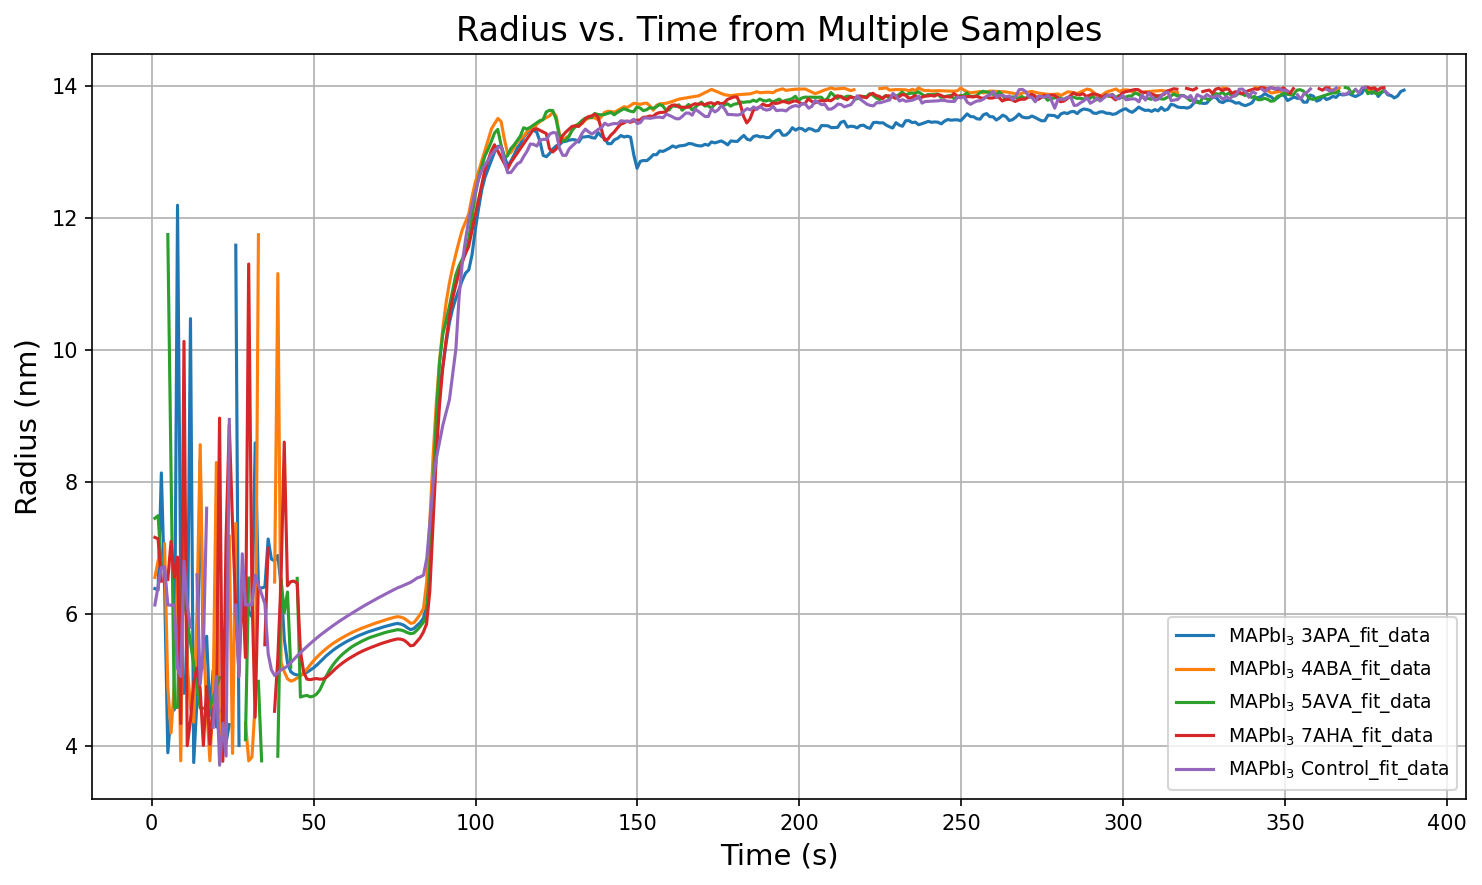

In [132]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
directory = "/Users/adamprintz/MAPbI3 Amino Acids PL"  # CHANGE THIS to the correct path where your Excel files are stored
# For example: directory = "C:/Users/YourName/Documents/data" or "./data"
sheet_name = "Raw_Data"
x_col_index = 0  # First column (Time)
y_col_index = 2  # Third column (Radius)

# --- Check if directory exists ---
if not os.path.exists(directory):
    print(f"Directory '{directory}' does not exist. Please check the path.")
    # Create a sample plot instead of exiting
    plt.figure(figsize=(10, 6), dpi=150)
    plt.text(0.5, 0.5, f"Directory '{directory}' not found.\nPlease update the 'directory' variable.", 
             horizontalalignment='center', verticalalignment='center', fontsize=14)
    plt.axis('off')
    plt.show()
else:
    # --- Plot initialization ---
    plt.figure(figsize=(10, 6), dpi=150)

    # --- Iterate over Excel files ---
    files_found = False
    for filename in os.listdir(directory):
        if filename.endswith(".xlsx"):
            files_found = True
            filepath = os.path.join(directory, filename)
            try:
                # Read the Raw_Data sheet
                df = pd.read_excel(filepath, sheet_name=sheet_name)

                # Get x (time) and y (radius) columns
                x = df.iloc[:, x_col_index]
                y = df.iloc[:, y_col_index]

                # Plot
                label = os.path.splitext(filename)[0]
                plt.plot(x, y, label=label)
            except Exception as e:
                print(f"Error processing {filename}: {e}")

    if not files_found:
        plt.text(0.5, 0.5, "No Excel files found in the directory.", 
                 horizontalalignment='center', verticalalignment='center', fontsize=14)
        plt.axis('off')
    else:
        # --- Plot formatting ---
        plt.xlabel("Time (s)", fontsize=14)
        plt.ylabel("Radius (nm)", fontsize=14)
        plt.title("Radius vs. Time from Multiple Samples", fontsize=16)
        plt.legend(fontsize=9)
        plt.grid(True)
        plt.tight_layout()

    # --- Show plot ---
    plt.show()